# Sparse Bayesian Estimation

In [1]:
import numpy as np; 
import matplotlib.pyplot as plt; 
import cvxpy as cp; 
from scipy.stats import chi2; 

# np.random.seed(42) # In order to ensure reproducibility. You can use different seed values.

In [2]:
# Defining methods
hermitian = lambda array: np.conj(array).T; 


def steering_vector(sensor_pos: np.ndarray, ang_elev: float, ang_azim: float, wavelen: float) -> np.ndarray:
  omega = np.array([[np.sin(ang_elev)*np.cos(ang_azim)],
                    [np.sin(ang_elev)*np.sin(ang_azim)],
                    [np.cos(ang_elev)]]); 
  return np.exp(1j*2*np.pi/wavelen*sensor_pos.T@omega); 


def d_steering_vector(sensor_pos: np.ndarray, ang_elev: float, ang_azim: float, wavelen: float) -> np.ndarray:
  a = steering_vector(sensor_pos, ang_elev, ang_azim, wavelen); 
  d_omega = np.array([[np.cos(ang_elev)*np.cos(ang_azim)],
                      [np.cos(ang_elev)*np.sin(ang_azim)],
                      [-np.sin(ang_elev)]]); 
  return -1j*2*np.pi/wavelen*a*sensor_pos.T@d_omega; 


def generate_pos_1d_ula(N: int, d: float, axis=(1.,0.,0.), x_init=(0.,0.,0.)) -> np.ndarray:
  if len(axis) != 3:
    raise TypeError(f"""The axis argument represents a 3D Cartesian vector.
      The length of the input ({len(axis)}) does not match with expected
      size 3."""); 
  if sum(axis) != 1:
    axis_new = (x/sum(axis) for x in axis); 
    axis = axis_new; 

  if len(x_init) != 3:
    raise TypeError(f"""The x_init argument represents a 3D cartesian vector.
      The length of the input ({len(x_init)}) does not match with expected
      size 3."""); 

  sensor_pos = np.tile(x_init, N).reshape(N,3).T \
    + (np.arange(0,N,1)*d) * np.tile(np.array(axis), N).reshape(N,3).T; 
  return sensor_pos; 


def calculate_crb(sensor_pos: np.ndarray, N: int, T: int, wl: float, angs_elev: np.ndarray, snr_db: float, S_db: list) -> np.ndarray:
  noise_pow = 10**(-snr_db/10); 
  sig_pow = [10**(s_db/10) for s_db in S_db]; 
  R_ss = np.diag(np.array(sig_pow)); 

  K = angs_elev.shape[0]; 

  # Steering matrix (A_mat) Derivative matrix (D_mat) of steering vectors w.r.t angles (in degrees)
  A_mat = np.zeros((N, K), dtype=complex); 
  D_mat = np.zeros((N, K), dtype=complex); 

  for i, theta in enumerate(angs_elev):
    A_mat[:,i] = steering_vector(sensor_pos, np.deg2rad(theta), np.deg2rad(0), wl)[:,0]; 
    D_mat[:,i] = d_steering_vector(sensor_pos, np.deg2rad(theta), np.deg2rad(0), wl)[:,0]; 

  Rxx_true = A_mat@R_ss@hermitian(A_mat) + noise_pow*np.eye(N); 
  Rxx_inv = np.linalg.inv(Rxx_true); 

  P_A_perp = np.eye(N) - A_mat@np.linalg.inv(hermitian(A_mat)@A_mat)@hermitian(A_mat); # Projection matrix onto the noise subspace

  # The Fisher Information Matrix components
  term1 = hermitian(D_mat) @ P_A_perp @ D_mat; 
  term2 = (R_ss @ hermitian(A_mat) @ Rxx_inv @ A_mat @ R_ss).T; 

  FIM = (2*T/noise_pow) * np.real(term1*term2); 

  return np.linalg.inv(FIM); 


def generate_random_targets(ang_min: float, ang_max: float, ang_dist: float, K: int) -> np.ndarray:
  while True:
    angs = np.random.uniform(ang_min, ang_max, K); 
    angs_sort = np.sort(angs); 
    for i in range(K-1):  # break for if is not valid
      is_valid = np.abs(angs_sort[i+1] - angs_sort[i]) >= ang_dist; 
      if not is_valid:
        break; 
    if is_valid: break;   # break while if is valid
  return angs; 

## Parameters
* $c$: Speed of light, assumed to be rounded to $30*10^8\text{ m/s}$.
* $f$: Frequency of the target signals in Herz, chosen as $5\text{ GHz}$
* $\lambda$: Wavelength of the target signals in meters. It is calculated as $\lambda = \frac{c}{f}$, which gives $6\text{ cm}$.

Next step is to determine the ULA parameters.

* $N$: # of antenna elements. We will choose this value as $16$.
* $T$: # of snapshots. Similar to $l_{1}$-SVD, we will go with $100$ snapshots.
* $K$: # of targets, chosen as 5. 

In [3]:
# Defining parameters
c = 3*1e8;      # The speed of light in vacuum (m/s)
f_c = 5*1e9;    # Narrowband signal frequency (Hz)
f_s = 100*1e9;  # Receiver sampling frequency (Hz)
wl = c/f_c;     # Signal wavelenght (m)
d = wl/2;       # Antenna distance (m)

N = 16;         # Number of antennas
T = 100;        # Number of snapshots
K = 3;          # Number of targets

S_db = [0]*K;   # Target signal power (dB)
snr_db = 10.0;  # Signal-to-Noise Ratio (dB)

ang_azim = 0;   # Azimuth angle (deg)
ang_min = -60;  # Minimum elevation angle (deg)
ang_max = 60;   # Maximum elevation angle (deg)
ang_dist = 5;   # Minimum distance between targets (deg)
ang_res = 1;  # Angular resolution in scanning (deg)

sensor_pos = generate_pos_1d_ula(N, d);                                 # Sensor position
theta_scan = np.arange(-90,90+ang_res,ang_res);                         # Angle scan
true_angles = generate_random_targets(ang_min, ang_max, ang_dist, K);   # Target elevation angles

for k in range(K):
  print(f"Target {k} True Angle: {true_angles[k]:.3f}°"); 

Target 0 True Angle: 29.017°
Target 1 True Angle: 54.375°
Target 2 True Angle: -56.272°


In [4]:
# Data Generation
A = np.column_stack([steering_vector(sensor_pos, np.deg2rad(theta), np.deg2rad(0), wl) for theta in true_angles]); # Array Steering Matrix
S_amp = np.diag([np.sqrt(10**(s_db / 10)) for s_db in S_db]); 
S = S_amp @ (np.random.randn(K, T) + 1j*np.random.randn(K, T))/np.sqrt(2); # Target Signals: Uncorrelated Gaussian (variance = 1.0)

# Noise: Spatially white complex Gaussian noise
noise_pow = 10**(-snr_db/10); 
Noise = np.sqrt(noise_pow) * (np.random.randn(N, T) + 1j*np.random.randn(N, T))/np.sqrt(2); 

# Received Signal at the Array
X = A @ S + Noise; 
R_xx = (X @ hermitian(X))/T;      # Sample covariance matrix

## The Signal Model
Classical SBE frames the process of collecting multiple responses (snapshots) over time as a *Simultaneous Sparse Approximation* or *Multiple Measurement Vector* (MMV) problem. Let's give a reminder of the signal model is expressed in the form of a sparse generative model, which is essentially same as in the $l_{1}$-SVD method.

$$
\mathbf{X} = \mathbf{\Phi} \mathbf{W} + \mathbf{\Eta}
$$

* $\mathbf{X} = [\mathbf{x}(1), \dots, \mathbf{x}(T)] \in \mathbb{C}^{N \times T}$: The observed target signals or responses across $T$ distinct snapshots, and each vector $\mathbf{x}(t) \in \mathbb{C}^{N}$ for $t \in \{1, \dots, T\}$ is a certain snapshot collected at a particular time $t$.

* $\mathbf{\Phi} \in \mathbb{C}^{N \times M}$: A pre-defined overcomplete dictionary ($M \gg N$) of basis vectors. In this particualr problem, these basis vectors are essentially steering vectors representing an array manifold corresponding to a discrete grid of potential angles ($\mathbf{\Phi} = \mathbf{A}_{\text{grid}} = []$).

* $\mathbf{W} = [\mathbf{w}(1), \dots, \mathbf{w}(T)] \in \mathbb{R}^{M \times T}$: The matrix of unknown weights to be estimated, where each weight $\mathbf{w}(t) \in \mathbb{R}^{M}$ at particular time $t$ is assumed to be the same $K$-sparse support vector of the particular snapshot $\mathbf{x}(t)$.

* $\mathbf{\Eta}$: An $N \times T$ matrix representing additive noise. 

The foundational assumption of this model is that all $T$ responses share an equivalent sparsity profile. This means that while the amplitudes of the weights in $W$ may change from snapshot to snapshot, the indices of the non-zero rows do not. Physically, this implies that a small, common subset of spatial angles (basis columns in $\mathbb{\Phi}$) is responsible for generating all the observed signals. The objective is to identify these active rows in $\mathbb{W}$. 

## Sparsity Solver via SBE

A more traditional approach is to try to find the sparsest solution by minimizing a row-diversity penalty directly via *Maximum A Posteriori* (MAP) estimation. However, highly sparse priors introduce a combinatorial explosion of suboptimal local minima, while weaker convex relaxations (like $l_{1}$-norm solvers) often fail to yield sufficiently sparse solutions.

SBE sidesteps this problem using Automatic Relevance Determination (ARD). Instead of hunting for a single problematic mode, it treats the weights $W$ as hidden variables and introduces a vector of hyperparameters $\mathbf{\gamma} = [\gamma_1, \dots, \gamma_M]^T$ to control the prior variance of each row. 

### The Hierarchical Prior Setup

The noise is modeled as a zero-mean Gaussian with variance $\sigma_{\eta}^{2}$, giving a conditional distribution for each response column

$$
p(\mathbf{x}(j) \vert{} \mathbf{w}(j)) = (2 \pi \sigma_{\eta}^{2})^{-N/2} \exp \left(-\frac{1}{2 \sigma_{\eta}^{2}} \Vert{}\mathbf{x}(j) - \mathbf{\Phi} \mathbf{w}(j)\Vert{}_2^2\right)
$$

Every $m$-th row of $\mathbf{W}$ (denoted $\mathbf{w}_{m}$) is assigned an $T$-dimensional Gaussian prior modulated by its own unique hyperparameter variance $\gamma_{m}$.

$$
p(\mathbf{w}_{m}; \gamma_{m}) = \mathcal{N}(0, \gamma_{m} I)
$$

The complete weight prior is the product of the individual row priors.

$$
p(W; \gamma) = \prod_{i=1}^M p(w_{m}; \gamma_{m})
$$

If a hyperparameter $\gamma_{m}$ is driven to exactly zero during estimation, it forces the posterior probability mass of that entire row to collapse to zero ($w_{m} = 0$), pruning that inactive dictionary component from the model.

### Expectation-Maximization (EM)

To find the optimal hyperparameters, the unknown weights $W$ are treated as nuisance parameters and integrated out (marginalized). We then maximize the marginal likelihood with respect to $\gamma$. This transforms the problem into minimizing the SBE cost function

$$
\mathcal{L}(\gamma) = T \log \vert{}\Sigma_{x}\vert{} + \sum_{t=1}^{T} \mathbf{x}^T(t) \Sigma_{x}^{-1} \mathbf{x}(t)
$$

Where the expected data covariance matrix is defined as $\Sigma_{x} = \sigma^2 \mathbf{I}_{N} + \mathbf{\Phi} \Gamma \mathbf{\Phi}^T$, and $\Gamma = \text{diag}(\gamma)$. 

The general SBE loop is defined as follows;

**Step 1**: The hyperparameter vector $\mathbf{\gamma}$ is initialized by setting all elements $\gamma_m = 1$ (or to non-negative random values). The noise variance $\sigma_{\eta}^{2}$ is assumed to be known. 

**Step 2**: Using the current estimates of $\mathbf{\gamma}$, the posterior covariance matrix $\Sigma$ and the posterior mean matrix $\mathcal{M} = [\mu(1), \dots, \mu(T)] \in \mathbb{R}^{M \times T}$ for the weights are computed:

$$
\Sigma = \mathbf{\Gamma} - \mathbf{\Gamma} \mathbf{\Phi}^T \Sigma_{x}^{-1} \mathbf{\Phi} \mathbf{\Gamma}
\\
\mathcal{M} = \mathbf{\Gamma} \mathbf{\Phi}^T \Sigma_x^{-1} \mathbf{X}
$$

**Step 3**: The variance hyperparameter $\gamma_m$ is updated for each row $m = 1, \dots, M$. There are two primary ways to achieve this:

* **The EM Update Rule**: It is the main method. It provides slower but stable convergence.

$$
\gamma_m^{(\text{new})} = \frac{1}{T}\Vert{}\mu_{m}\Vert{}_2^2 + \sigma_{mm}
$$

* **The Fixed-Point Update Rule**: This provides faster convergence for large-scale problems.

$$\gamma_m^{(\text{new})} = \frac{\frac{1}{T}\Vert{}\mu_{m}\Vert{}_2^2}{1 - \gamma_{m}^{-1}\sigma_{mm}}$$

$\mu_{i.}$ is the $i$-th row of the posterior mean matrix $\mathcal{M}$, and $\sigma_{mm}$ is the $i$-th diagonal element of the posterior covariance $\Sigma$.

**Step 4**: Steps 2 and 3 provide the main iteration. As the algorithm iterates, many elements in $\gamma$ will naturally drop toward zero. In practice, any hyperparameter that falls below an arbitrarily small threshold (e.g., $10^{-16}$) is completely pruned from the model along with its corresponding dictionary column in $\Phi$ and row in $W$, drastically speeding up the remaining calculations.

**Step 5**: Once the hyperparameters converge to a stable sparse vector $\gamma^*$, the final point estimate for the signal weights is drawn directly from the final posterior mean:

$$
W_{\text{M-SBL}} = \mathcal{M}^*
$$

Because $\gamma^*$ is highly sparse, the resulting rows of $W_{\text{M-SBL}}$ are strictly row-sparse, pointing you directly to the accurate DoA grid angles.

In [14]:
Phi = np.column_stack([steering_vector(sensor_pos, np.deg2rad(theta), np.deg2rad(0), wl) for theta in theta_scan]); 
M = len(theta_scan); 

gamma = np.ones(M);         # Initial hyperparameters (gamma_i > 0)

for iteration in range(500):
  gamma_prev = gamma.copy(); 

  Gamma = np.diag(gamma); 
  Phi_H = hermitian(Phi); 
  Sigma_xx = noise_pow * np.eye(N) + Phi @ Gamma @ Phi_H; 
  Sigma_xx_inv = np.linalg.inv(Sigma_xx); 

  Mu = Gamma @ Phi_H @ Sigma_xx_inv @ X; 

  diag_Phi_Sigma_Phi = np.real(np.sum(Phi.conj() * (Sigma_xx_inv @ Phi), axis=0)); 
  sigma_ii = gamma-(gamma**2)*diag_Phi_Sigma_Phi; 
  sigma_ii = np.clip(sigma_ii, 0, None); 

  mu_row_power = np.sum(np.abs(Mu)**2, axis=1) / T; 

  # Updating gamma
  gamma = mu_row_power + sigma_ii;       # Expectation-Maximization
  #denom = 1.0 - sigma_ii / (gamma + 1e-16); # Fast Fixed-Point
  #denom = np.clip(denom, 1e-6, None); # To prevent division-by-zero
  #gamma = mu_row_power / denom; 

  if np.linalg.norm(gamma - gamma_prev) / (np.linalg.norm(gamma_prev) + 1e-16) < 1e-4:
    break; 

# Final point estimate of the weights is the posterior mean matrix
W_est_sbe = Gamma @ Phi_H @ np.linalg.inv(noise_pow * np.eye(N) + Phi @ Gamma @ Phi_H) @ X; 

w_est_sbe_avg = np.abs(np.sum(W_est_sbe, axis=1)); 
w_est_sbe_avg = w_est_sbe_avg / max(w_est_sbe_avg); 

### Visualization

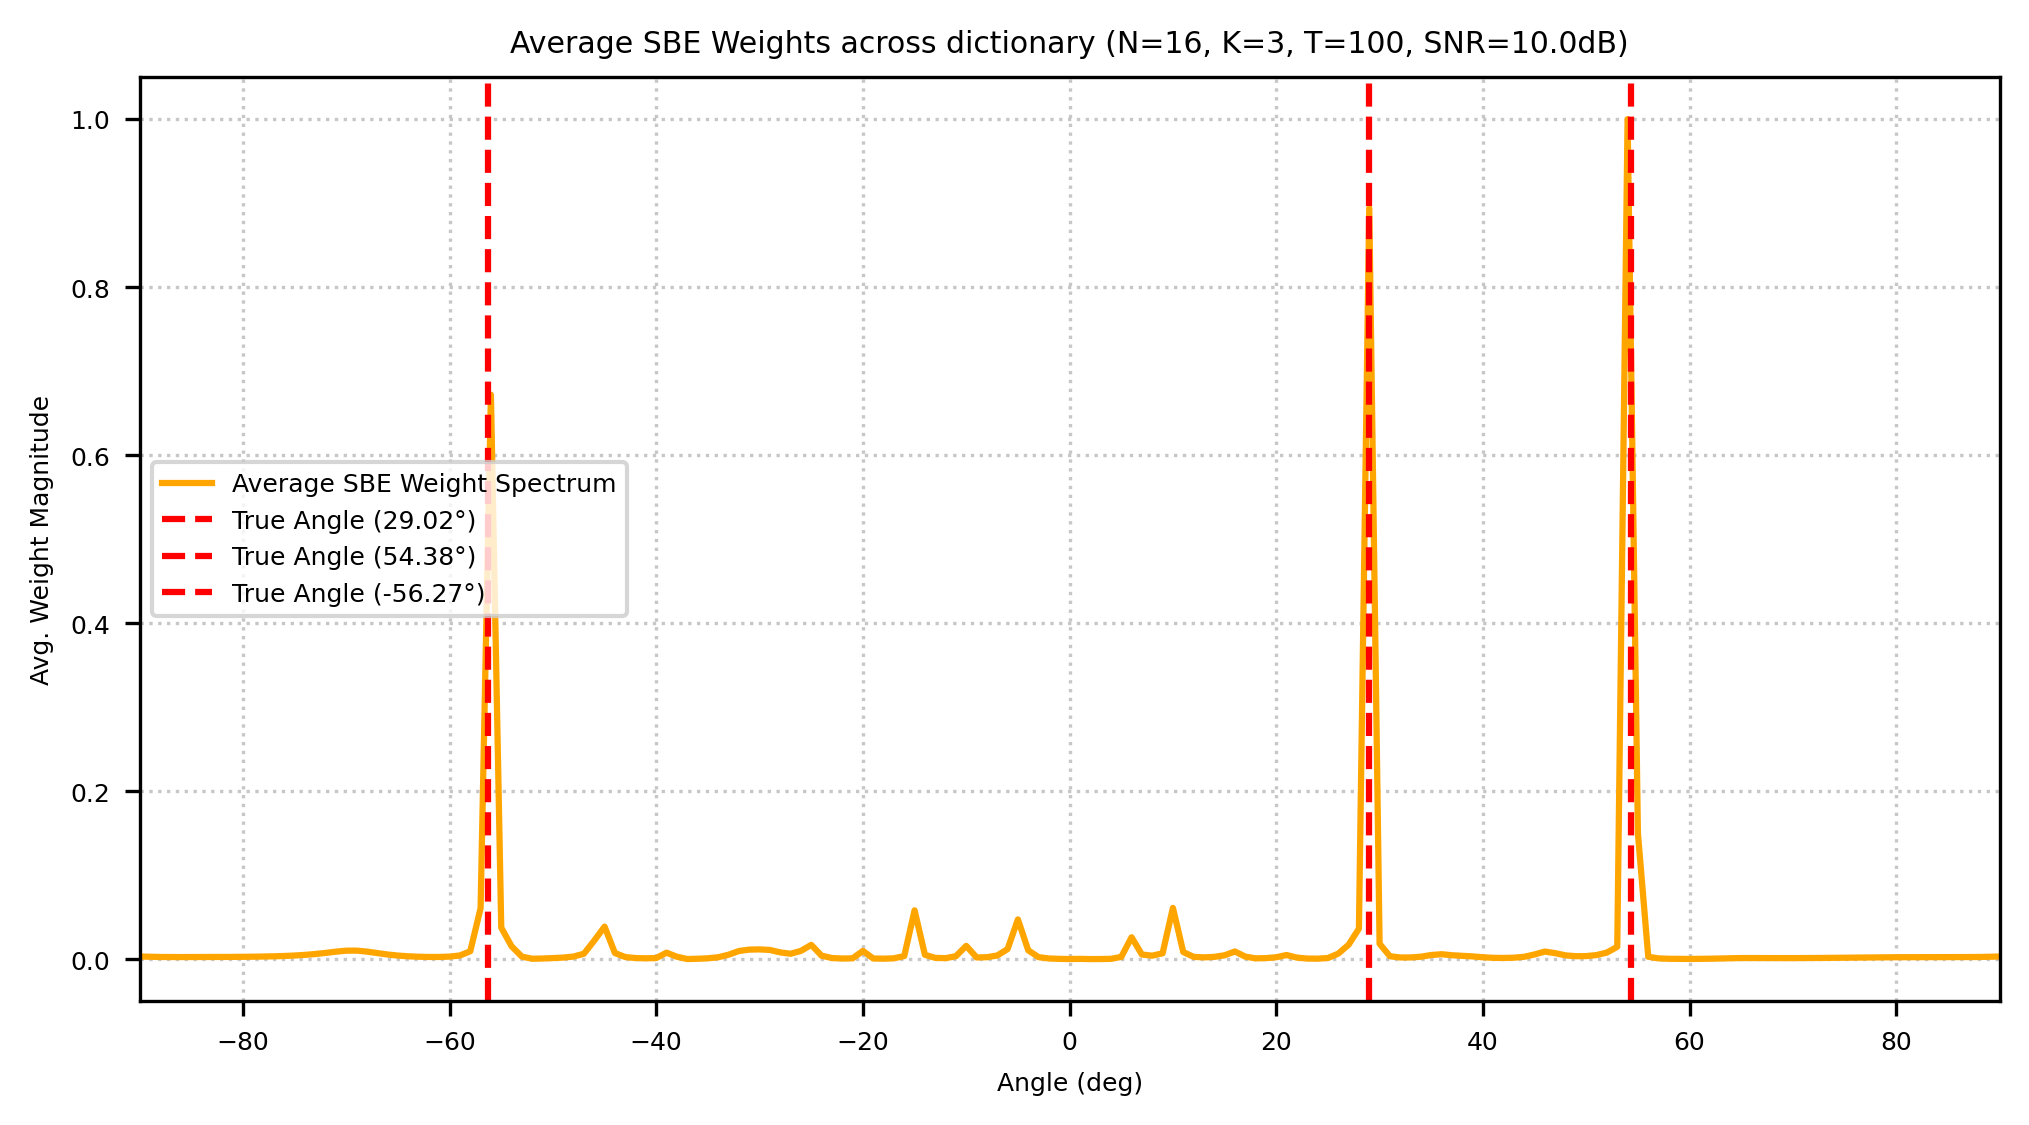

In [ ]:
plt.rcParams.update({'font.size': 6}); 

plt.figure(figsize=(8,4), dpi=300); 
plt.plot(theta_scan, w_est_sbe_avg, color='orange', label="Average SBE Weight Spectrum"); 

for i, angle in enumerate(true_angles):
    plt.axvline(x=angle, color='red', linestyle='--',
                label=f'True Angle ({angle:.2f}°)'); 

plt.title(f"Average SBE Weights across dictionary (N={N}, K={K}, T={T}, SNR={snr_db}dB)"); 
plt.xlim([-90, 90]); plt.ylim([-0.05, 1.05]); 
plt.xlabel("Angle (deg)"); plt.ylabel("Avg. Weight Magnitude"); 
plt.grid(True, linestyle=':', alpha=0.7); 

handles, labels = plt.gca().get_legend_handles_labels(); 
by_label = dict(zip(labels, handles)); 
plt.legend(by_label.values(), by_label.keys(), loc="center left"); 

In [ ]:
def doa_sbe(
    X: np.ndarray, 
    theta_scan: np.ndarray, 
    sensor_pos: np.ndarray, 
    noise_pow: float,
    wl: float, 
    max_iter: int = 1000, 
    tol: float = 1e-4, 
    update_type: str = "fp", 
    learn_noise: bool = False):
  """
  Method that implements Sparse Bayesian Estimation algorithm for 
    Direction-of-Arrival estimation.

  --Inputs--
  X: Received sensor snapshot matrix. Type of np.ndarray of size (N,T) 
    and dtype of np.complex128.
  theta_scan: The angle grid span in degrees. Type of np.ndarray of size (M,) 
    and dtype of np.float64.
  sensor_pos: Antenna element positions in 3D Cartesian coordinates. Type of 
    np.ndarray of size (3,N) and dtype of np.float64.
  noise_pow: Noise power (variance) of the received signal. Type of float.
  wl: Wavelength of the received signal. Type of float.
  max_iter: Maximum number of EM iterations. Type of int.
  tol: Convergence tolerance for the EM algorithm. Type of float.
  update_type: Type of hyperparameter update method. Can be either "em" for
    Expectation-Maximization or "fp" for Fast Fixed-Point. Type of str.
  learn_noise: Boolean flag to indicate whether to learn the noise variance
    automatically during the EM iterations. Type of bool.
    
  --Outputs--
  W_est: Estimated source signals. Type of np.ndarray of size (M,T) and dtype of np.complex128.
  gamma: Estimated hyperparameters. Type of np.ndarray of size (M,) and dtype of np.float64.
  history: Convergence history of the EM algorithm. Type of list of float.
  """

  Phi = np.column_stack([steering_vector(sensor_pos, np.deg2rad(theta), np.deg2rad(0), wl) for theta in theta_scan]); 
  N, M = Phi.shape; 
  T = X.shape[1]; 

  gamma = np.ones(M);                           # Initial hyperparameters (gamma_i > 0)
  history = []; 

  for iter in range(max_iter):
    gamma_prev = gamma.copy(); 
        
    # Data covariance Component
    Gamma = np.diag(gamma); 
    Phi_H = hermitian(Phi); 
    Sigma_x = noise_pow * np.eye(N) + Phi @ Gamma @ Phi_H; 
    Sigma_x_inv = np.linalg.inv(Sigma_x); 
        
    M_mat = Gamma @ Phi_H @ Sigma_x_inv @ X;       # Posterior Mean Matrix
        
    # Computing Diagonal elements of Posterior Covariance Matrix
    diag_Phi_Sigma_Phi = np.real(np.sum(Phi.conj() * (Sigma_x_inv @ Phi), axis=0)); 
    sigma_ii = gamma - (gamma ** 2) * diag_Phi_Sigma_Phi; 
    sigma_ii = np.clip(sigma_ii, 0, None); 
        
    mu_row_power = np.sum(np.abs(M_mat) ** 2, axis=1) / T; 
    
    if update_type == 'em':                     # Expectation-Maximization
      gamma = mu_row_power + sigma_ii; 
    elif update_type == 'fp':                   # Fast Fixed-Point
      denom = 1.0 - sigma_ii / (gamma + 1e-16); 
      denom = np.clip(denom, 1e-6, None); 
      gamma = mu_row_power / denom; 
    
    if learn_noise:                             # Optional automatic true noise variance learning
      residual = X - Phi @ M_mat; 
      num_noise = np.sum(np.abs(residual) ** 2) / T; 
      denom_noise = N - M + np.sum(sigma_ii / (gamma + 1e-16)); 
      if denom_noise > 1e-6:
        noise_pow = num_noise / denom_noise; 
        
    # Track convergence metric
    diff = np.linalg.norm(gamma - gamma_prev) / (np.linalg.norm(gamma_prev) + 1e-16); 
    history.append(diff); 
      
    if diff < tol:
      break; 
            
  W_est = Gamma @ Phi_H @ np.linalg.inv(noise_pow * np.eye(N) + Phi @ Gamma @ Phi_H) @ X; 
  return W_est, gamma, history; 

## Off-Grid Sparse Bayesian Estimation
When real-world signals do not land perfectly on our pre-defined mathematical grid, classical SBL runs into a roadblock. Let's look at how the framework adapts to continuous space using off-grid modeling. In the classical setup, we assume the true Direction-of-Arrival (DoA) angles $\theta$ align perfectly with the columns of our discrete dictionary matrix $\Phi$. In reality, a target source can impinge from any continuous angle.

### The Grid Mismatch Problem
When a source falls between two grid points, the signal's energy gets smeared across multiple adjacent grid points. The algorithm sees this leakage as multiple weak sources rather than one sharp, true source. As a result, the spatial resolution drops significantly, and the grid bias creates a hard ceiling on how accurate your estimates can be.

To fix this, we could make the grid infinitely dense, but that explodes the size of $\Phi$, turning the matrix inversions into a computational nightmare. Off-grid SBL solves this elegantly by making the grid flexible.

### The Off-Grid Signal Model

Instead of a rigid dictionary, off-grid SBL introduces a perturbation or offset parameter. Let $\tilde{\theta}_n$ be the nearest discrete grid point to a true, continuous angle $\theta_k$. We define the spatial offset as:

$$
\beta_n = \theta_k - \tilde{\theta}_n
$$

Since $\tilde{\theta}_n$ is the closest point, the offset is naturally bounded by half the grid interval $\Delta$: $\beta_n \in [-\frac{\Delta}{2}, \frac{\Delta}{2}]$. We can approximate the true, continuous steering vector $a(\theta_k)$ using a first-order Taylor linear expansion around its neighbor $\tilde{\theta}_n$.

$$
a(\theta_k) \approx a(\tilde{\theta}_n) + b(\tilde{\theta}_n)\beta_n
$$

Here, $b(\tilde{\theta}_n) = \frac{\partial a(\theta)}{\partial \theta} \Big\vert{}_{\theta = \tilde{\theta}_n}$ represents the partial derivative of the steering vector with respect to the angle, evaluated at the grid point.

By stacking these approximations for every grid point, we construct a derivative dictionary matrix $\mathbf{B} = [b(\tilde{\theta}_1), \dots, b(\tilde{\theta}_M)]$. The MMV signal model gets updated to:

$$
\mathbf{X} = (\Phi + \mathbf{B}\text{diag}(\beta))\mathbf{W} + \mathbf{\Eta}
$$

Here, $\beta = [\beta_1, \dots, \beta_M]^T$ is a vector containing the continuous grid adjustments. If a grid point has no source nearby, its corresponding weight row in $W$ drops to zero, rendering its offset irrelevant.

### Algorithmic Evolution - Joint Optimization

With this new formulation, $\beta$ joins the hyperparameter vector $\gamma$ and the noise variance $\sigma^2$ as an unknown variable that must be learned from the data. The iterative algorithm shifts from a simple sparse recovery tool to a joint estimation and refinement loop.

* **The Expectation Step**:The calculations for the posterior covariance $\Sigma$ and posterior mean $\mathcal{M}$ follow the same logic as the classical version, but they now use the parameter-adjusted dictionary $\mathbf{\Phi}(\beta) = \mathbf{\Phi} + \mathbf{B}\text{diag}(\beta)$:

$$
\Sigma_{x} = \sigma_{\eta}^{2} I + \Phi(\beta)\Gamma\Phi(\beta)^T
$$

$$
\Sigma = \mathbf{\Gamma} - \mathbf{\Gamma} \mathbf{\Phi}(\beta)^T \Sigma_{x}^{-1} \mathbf{\Phi}(\beta) \mathbf{\Gamma}
$$

$$
\mathcal{M} = \mathbf{\Gamma} \mathbf{\Phi}(\beta)^T \Sigma_{x}^{-1} \mathbf{X}
$$

* **The Maximization Step**: During the maximization step, we update the offsets $\beta$ by minimizing the expected reconstruction residual. The optimization problem targets:

$$
\min_{\beta} \mathbb{E}_{\mathbf{W}\vert{}\mathbf{X}} \left[ \Vert{}\mathbf{X} - (\mathbf{\Phi} + \mathbf{B}\text{diag}(\beta))\mathbf{W}\Vert{}_F^2 \right]
$$

Because this is quadratic with respect to $\beta$, we can differentiate the objective function and solve for each offset $\beta_n$. The update rule uses the calculated posterior moments ($\mathcal{M}$ and $\Sigma$) to quantify the error and calculate exactly how far to shift the grid point to minimize the residual.

* **Dynamic Grid Refinement**: In advanced off-grid implementations (often called dynamic grid SBL or Root-SBL variants), the algorithm doesn't just calculate $\beta$ as a static correction factor. Instead, at the end of every iteration, it physically moves the grid points:

$$\tilde{\theta}_n^{(\text{new})} = \tilde{\theta}_n^{(\text{old})} + \beta_n$$

As the algorithm updates, the grid points literally "walk" toward the true continuous angles. Once the grid shifts, $\Phi$ and $B$ are re-computed based on the brand-new angles, $\beta_n$ is reset to zero, and the loop repeats.

By the time the hyperparameters converge, the active grid points are sitting directly on top of the true continuous source positions, completely eliminating grid mismatch bias while maintaining a coarse, computationally friendly dictionary.

Now that you see how the algorithm adjusts dynamically to track continuous sources, we are ready to look at a concrete implementation approach.

In [ ]:
def doa_off_grid_sbe(
    X: np.ndarray, 
    theta_scan: np.ndarray, 
    sensor_pos: np.ndarray, 
    grid_res: float, 
    wl: float, 
    max_iter: int = 1000, 
    tol: float = 1e-4
    ) -> tuple:
  """
  Off-Grid Sparse Bayesian Estimation.
    
  Parameters:
  -----------
  X : np.ndarray
    Received sensor snapshot matrix of shape (N, T)
  theta_scan : np.ndarray
    The coarse grid of angles in degrees
  grid_res : float
    The step size of the search grid in radians (Delta)
  max_iter : int
    Maximum number of EM iterations
  tol : float
    Convergence tolerance for the sparse prior vector
        
  Returns:
  --------
  gamma : np.ndarray
    Estimated spatial sparse prior profile vector of shape (M,)
  beta : np.ndarray
    Estimated grid parameter offsets vector of shape (M,)
  noise_var : float
    Estimated noise variance
  """

  Phi = np.column_stack([steering_vector(sensor_pos, np.deg2rad(theta), np.deg2rad(0), wl) for theta in theta_scan]); 
  D = np.column_stack([d_steering_vector(sensor_pos, np.deg2rad(theta), np.deg2rad(0), wl) for theta in theta_scan]); 

  N, M = Phi.shape; 
  T = X.shape[1];  # Number of snapshots
    
  # Initializing hyperparameters
  gamma = np.ones(M) * np.mean(np.abs(hermitian(Phi) @ X)**2, axis=1); 
  noise_var = np.mean(np.abs(X)**2) / 100; 
  beta = np.zeros(M); 

  # Precompute the diagonal elements of D^H * D to optimize the denominator
  D_H_D_diag = np.sum(np.abs(D)**2, axis=0); 
    
  # Set hard boundaries for grid offsets to prevent grid cell crossover
  beta_bound = grid_res / 2.0; 
    
  for iteration in range(max_iter):
    gamma_prev = gamma.copy(); 
        
    A = Phi + D @ np.diag(beta);              # Effective steering matrix with current offsets
        
    # 2. Expectation Step (Posterior Covariance & Mean using Woodbury Identity)
    # Rxx = noise_var * I + A * Gamma * A^H
    R_xx = noise_var * np.eye(N) + (A * gamma) @ hermitian(A); 
    R_xx_inv = np.linalg.inv(R_xx); 

    # Compute Posterior Metrics
    # Sigma_w = Gamma - Gamma * A^H * Rxx^(-1) * A * Gamma
    Gamma_A_H = hermitian(A * gamma); 
    Sigma_w = np.diag(gamma) - Gamma_A_H @ R_xx_inv @ (A * gamma); 
    Mu_w = (1.0 / noise_var) * Sigma_w @ hermitian(A) @ X; 
        
    # 3. Maximization Step: Sparse Prior Vector (Gamma)
    Mu_w_sq = np.mean(np.abs(Mu_w)**2, axis=1); 
    gamma = Mu_w_sq + np.real(np.diag(Sigma_w)); 
        
    # 4. Maximization Step: Automatic Noise Variance Update
    residual = X - A @ Mu_w; 
    trace_term = np.real(np.trace(A @ Sigma_w @ hermitian(A))); 
    noise_var = (np.sum(np.abs(residual)**2) / T + trace_term) / N; 
    noise_var = max(noise_var, 1e-8);  # Prevent underflow
        
    # 5. Maximization Step: Grid Offset Parameters Optimization (Beta)
    R_out = Mu_w @ hermitian(Mu_w) + T * Sigma_w; 

    D_H_Y_Mu_H = hermitian(D) @ X @ hermitian(Mu_w); 
    D_H_Phi_R = hermitian(D) @ Phi @ R_out; 
    R_out_diag = np.real(np.diag(R_out)); 
        
    # Compute decoupled updates for grid points
    numerator = np.real(np.diag(D_H_Y_Mu_H) - np.diag(D_H_Phi_R)); 
    denominator = D_H_D_diag * R_out_diag + 1e-12; 
        
    beta = numerator / denominator; 
    beta = np.clip(beta, -beta_bound, beta_bound); 
        
    # 6. Check Convergence Criterion
    if np.linalg.norm(gamma - gamma_prev) / (np.linalg.norm(gamma_prev) + 1e-12) < tol:
      break; 
            
  return gamma, beta, noise_var; 

import numpy as np
from scipy.signal import find_peaks

def extract_refined_angles(
    gamma: np.ndarray, 
    beta: np.ndarray, 
    grid_angles: np.ndarray,                        
    K: int = None, 
    rel_threshold: float = 0.05) -> tuple:
  """
  Extracts and computes the numerically corrected true angles from the 
  Off-Grid SBE estimation results.

  Parameters:
  -----------
  gamma : np.ndarray
    Estimated spatial sparse prior profile vector of shape (M,)
  beta : np.ndarray
    Estimated grid parameter offsets vector of shape (M,)
  grid_angles : np.ndarray
    The coarse scanning grid array of shape (M,) (e.g., in degrees or radians)
  K : int, optional
    The known number of targets to extract. If None, relies purely on the threshold.
  rel_threshold : float
    Minimum height threshold for peaks, relative to the global maximum peak value.
    
  Returns:
  --------
  refined_angles : np.ndarray
    The final numerically corrected true target angles.
  detected_indices : np.ndarray
    The coarse grid indices where the targets were isolated.
  """
  # Define an absolute execution threshold based on the maximum power found
  abs_threshold = rel_threshold * np.max(gamma)
    
  # 1. Isolate local maxima (peaks) to prevent cluster artifacts around a single source
  peaks, _ = find_peaks(gamma, height=abs_threshold)
    
  if len(peaks) == 0:
    print("Warning: No distinct spatial peaks crossed the target threshold.")
    return np.array([]), np.array([])
    
  # 2. Sort the discovered local peaks by their estimated power in descending order
  peaks_sorted_by_power = peaks[np.argsort(gamma[peaks])[::-1]]
    
  # 3. Filter down to the true target count K if provided
  if K is not None:
    if len(peaks_sorted_by_power) < K:
      print(f"Warning: Only found {len(peaks_sorted_by_power)} peaks, but K={K} was requested.")
    detected_indices = peaks_sorted_by_power[:K]
  else:
    detected_indices = peaks_sorted_by_power

  # Sort indices ascending by angle orientation for structured data output
  detected_indices = np.sort(detected_indices)
    
  # 4. Apply the Off-Grid Correction Formula: theta_true = theta_grid + beta
  coarse_angles = grid_angles[detected_indices]
  learned_offsets = beta[detected_indices]
  refined_angles = coarse_angles + learned_offsets
  
  return refined_angles, detected_indices

In [ ]:
gamma, beta, noise_var = doa_off_grid_sbe(X, theta_scan, sensor_pos, ang_res, wl); 

refined_angles, detected_indices = extract_refined_angles(gamma, beta, theta_scan, K); 


In [35]:
refined_angles

array([-55.99451774,  28.99687717,  53.99168847])